## Homework 7   

Name: Acamaro Cutcher

Comments for grader:


### Problem 1 - Boundary value problem

Solve the differential equation:

$$
\frac{d^2y}{dt^2} = -g
$$

that governs the flight of a ball without air resistance, where $y$ is the height of the ball.  The boundary conditions are  y=0 0 m, at t=0, 10s. That is, the ball must last land at t=10s. We are not given the initial velocity.

Find the initial velocity, and using your solution make a plot of y(t) vs. time.


Note that the second order differential equations can be written as two first order differential equations. We have:
$$
\frac{dy}{dt} = v
$$
$$
\frac{dv}{dt} = -g
$$

The solution vector would be a 2D vector which would take the form:

$$
r = [ y, v ]
$$

and the gradient function would take the form:

$$
f(r,t) = [\frac{dy}{dt}, \frac{dv}{dt}]
$$

$$
f(r,t) = [v, -g]
$$

The problem now gives us the boundary conditions that the ball will be at position $y = 0$ at time $t = 0 \ s$ and $t = 10 \ s$. However, our first order differential equations tell us that we need two boundary condition the $y$ position and the starting velocity of the ball.

Since we are missing one of the boundary condition, we will use the shooting method, that is we will guess the starting velocity of the ball and check if the ball after 10 seconds reaches the correct hight y using the Runda-Kutta Method. If the ball does not reach the desired height within some error term, we must change the starting position and apply Runda-Kutta to make sure the ball's position meets our boundary condition. We repeat until we reach the desired result within some error term.


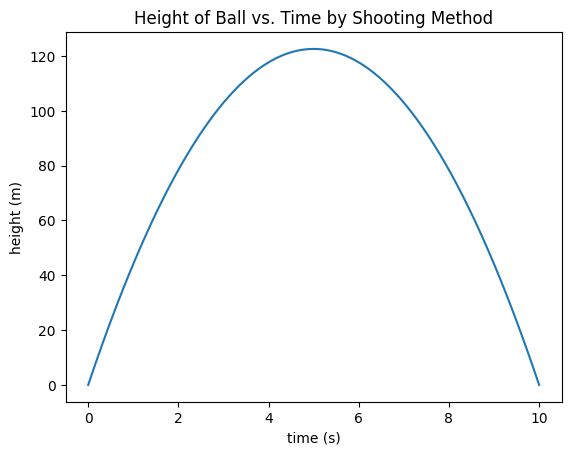

The ball starts at y = 0 with an initial velocity of 49.03324991464615  m/s at t = 0 s.
The ball will reach a height of  -8.535437648338196e-07 with an final velocity of -49.03325008535489  m/s at 10 seconds.


In [ ]:
# problem 1 code
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import g

mim_error = 1e-5

def rk4(f, t_start, t_end, N_steps, r0):

    h = (t_end - t_start)/N_steps
    time_steps = np.arange(t_start, t_end + h, h)

    r_approx = np.zeros((N_steps+1, 2)) # 2D array of zeros N_steps x 2
    r_approx[0]  = r0

    for i in range(1, time_steps.shape[0]):

        t = time_steps[i-1]
        r = r_approx[i-1]

        k_1 = h * f(r,t)
        k_2 = h * f(r + 1/2*k_1, t + 1/2 * h)
        k_3 = h * f(r + 1/2*k_2, t + 1/2 * h)
        k_4 = h * f(r + k_3, t + h)
        r_approx[i] = r + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

    return time_steps, r_approx

def f(r,t):
  v = r[1]
  return np.array([v, -g])

def binary(f, v_start, v_end, y0):
  N_steps = 1000
  t_start = 0
  t_end = 10

  v_mid = (v_start + v_end)/2

  r0 = np.array([y0, v_mid])

  time_steps, r_approx = rk4(f, t_start, t_end, N_steps, r0)
  y_mid = r_approx[-1,0]

  if(np.abs(y_mid) < mim_error):
    return time_steps, r_approx, v_mid
  else:
    if(y_mid > 0):
      return binary(f, v_start, v_mid, y0)
    else:
      return binary(f, v_mid, v_end, y0)


def display():

  time_steps, r_approx, v0 = binary(f, 0, 100, 0)

  plt.plot(time_steps, r_approx[:,0])
  plt.xlabel('time (s)')
  plt.ylabel('height (m)')
  plt.title('Height of Ball vs. Time by Shooting Method')
  plt.show()
  print("The ball starts at y = 0 with an initial velocity of", v0, " m/s at t = 0 s.")
  print("The ball will reach a height of ", r_approx[-1][0], "with an final velocity of", r_approx[-1][1], " m/s at 10 seconds.")



display()

#### Problem 1 Pts /10

### Problem 2: Cometary orbits - Adaptive step size

Many comets travel in highly elongated orbits around the Sun.  For much of their lives they are far out in the solar system, moving very slowly, but on rare occasions their orbit brings them close to the Sun for a fly-by and for a brief period of time they move very fast indeed (check your textbook for a diagram).

This is a classic example of a system for which an adaptive step size method is useful, because for the large periods of time when the comet is moving slowly we can use long time-steps, so that the program runs quickly, but short time-steps are crucial in the brief but fast-moving period close to the Sun.

The differential equation obeyed by a comet is straightforward to derive.  The force between the Sun, with mass $M$ at the origin, and a comet of mass $m$ with position vector $\vec{r}$ is $GMm/r^2$ in direction $-\vec{r}/r$ (i.e., the direction towards the Sun), and hence Newton's second law tells us that

\begin{equation*}
m {d^2\vec{r}\over d t^2} = -\biggl({GMm\over r^2}\biggr)\,{\vec{r}\over r}.
\end{equation*}

Canceling the $m$ and taking the $x$ component we have

\begin{equation*}
{d^2 x\over d t^2} = -GM {x\over r^3}\,,
\end{equation*}

and similarly for the other two coordinates.  We can, however, throw out one of the coordinates because the comet stays in a single plane as it orbits.  If we orient our axes so that this plane is perpendicular to the $z$-axis, we can forget about the $z$ coordinate and we are left with just two second-order equations to solve:

\begin{equation*}
{d^2 x\over d t^2} = -GM {x\over r^3}\,, \qquad
{d^2 y\over d t^2} = -GM {y\over r^3}\,,
\end{equation*}

where $r=\sqrt{x^2+y^2}$.

**a)**
Turn these two second-order equations into four first-order equations, using the methods you have learned.

**Solution:**

To solve these two second-order equations into first-order equations we assign:
$$
\frac{dx}{dt} = v_x \ \ \ \text{and} \ \ \
\frac{dy}{dt} = v_y.
$$
We can then write:
$$
\frac{d v_x}{dt} = -G M \frac{x}{r^3} \ \ \ \text{and} \ \ \ \frac{d v_y}{dt} = -G M \frac{y}{r^3}
$$



**Pts /5**

**b)**
First write a program to solve your equations using the fourth-order Runge-Kutta method with a *fixed* step size.  You will need to look up the mass of the Sun and Newton's gravitational constant $G$.  As an initial condition, take a comet at coordinates $x=4$ billion kilometers and $y=0$ (which is somewhere out around the orbit of Neptune) with initial velocity $v_x=0$ and $v_y = 500\,\mathrm{m\,s}^{-1}$.  

Make a graph showing the trajectory of the comet (i.e., a plot of $y$ against $x$). Choose a fixed step size $h$ (or equivalently the number of time steps $N$) that allows you to accurately calculate at least one full orbit of the comet.  Since orbits are periodic, a good indicator of an accurate calculation is that successive orbits of the comet lie on top of one another on your plot.  If they do not, then you need a smaller value of $h$.

When finished, have your program:
1. Make a graph of the comet's trajectory. Label axes appropriately.
2. Plot a big yellow dot at the position of the Sun.
3. Plot a dot at every $n$th time step. Choose $n$ so you can see how the spacing of the dots changes around the trajectory. You can easily do this using array slicing. For example, if your x,y values are stored in x,y arrays, you can plot every $n$th value using x[::n],y[::n].
4. Output the total number of time steps and the length of each time step.
5. Output the period of the comet calculated from the number of time steps and length of each time step.

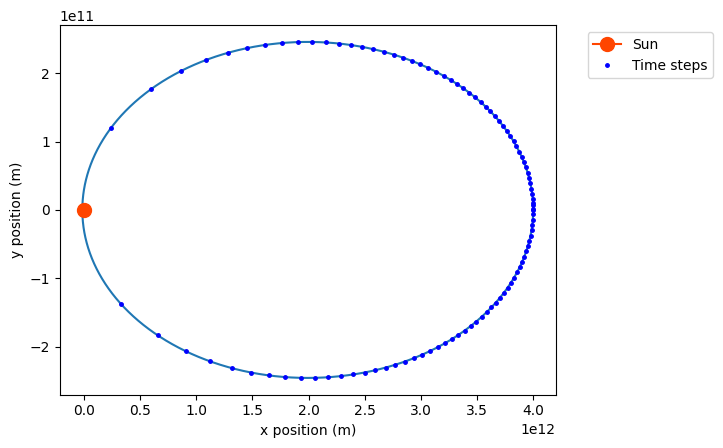

Initial position: ( 4000000000000.0 , 0.0 )
Final position: ( 3997935009942.1553 , 9510484968.89139 )

Total number of time steps: 100000
Length of each time step: 15700.0 seconds
The period of the comet is time steps x length of time step: 1570000000.0.


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

m_sun = 1.989e30 # kg

def f(l,t):
  """
  Note that l is a vector that has the following form
  l = [x,y,v_x, v_y] this is similar to what we know as the r vector.
  """
  x = l[0]
  y = l[1]
  v_x = l[2]
  v_y = l[3]
  r = np.sqrt(x**2 + y**2)
  dx = v_x
  dy = v_y
  dv_x = -G * m_sun * x / ((r)**3)
  dv_y = -G * m_sun * y / ((r)**3)

  return np.array([dx, dy, dv_x, dv_y])

def rk4(f, t_start, t_end, N_steps, l0):
    N_steps = int(N_steps)
    h = (t_end - t_start)/N_steps
    time_steps = np.arange(t_start, t_end + h, h)

    l_approx = np.zeros((N_steps+1, 4)) # 2D array of zeros N_steps x 2
    l_approx[0]  = l0

    for i in range(1, time_steps.shape[0]):
      t = time_steps[i-1]
      l = l_approx[i-1]

      k_1 = h * f(l,t)
      k_2 = h * f(l + 1/2*k_1, t + 1/2 * h)
      k_3 = h * f(l + 1/2*k_2, t + 1/2 * h)
      k_4 = h * f(l + k_3, t + h)

      l_approx[i] = l + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

    return time_steps, l_approx

# 4 billion km = 4e12 meters
l0 = np.array([4e12, 0, 0, 500])

# Manually tested different ending times we obtained good results for:
N_steps = 100000
t_end = 1.57e9
time_steps, l_approx = rk4(f, 0, t_end, N_steps, l0)

plt.plot(l_approx[:,0], l_approx[:,1])
plt.plot(0, 0, marker='o', color='orangered', markersize=10, label='Sun')
plt.plot(l_approx[::1000, 0], l_approx[::1000, 1], 'b.', markersize=5, label='Time steps')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Initial position: (",l0[0], ",", l0[1],")")
print("Final position: (", l_approx[-1][0], ",", l_approx[-1][1], ")")

# Output time steps info
h = t_end / N_steps
print(f"\nTotal number of time steps: {N_steps}")
print(f"Length of each time step: {h} seconds")
print(f"The period of the comet is time steps x length of time step: {t_end}.")


Explain the spacing of the dots along the trajectory of the comet.

**Response:**

The comet's velocity increases significatly has it approaches the sun. The change in spacing that we are noticing is in fact due to the change in velocity of the comet. We are therefore visualy seing that the comet speeds up when it is closer to the sun and slows down when it farther away.



**Pts /10**

**c)**
Now make a copy of your program and modify it to repeat the calculation this time using an adaptive step size.  Set a target accuracy of $\delta=1$ kilometer per year in the position of the comet and again plot the trajectory with dots at every $n$ interval. Output the number of time steps and average length of each time step.  

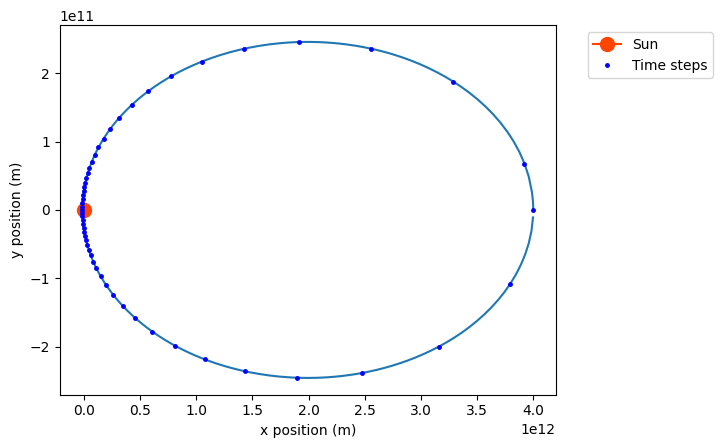

Initial position: ( 4000000000000.0 , 0.0 )
Final position: ( 3997995184335.9688 , -10989496531.057812 )

Total number of time steps: 526
Average length of each time step: 2907223.85 seconds


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

m_sun = 1.989e30 # kg

def f(l,t):
  """
  Note that l is a vector that has the following form
  l = [x,y,v_x, v_y] this is similar to what we know as the r vector.
  """
  x = l[0]
  y = l[1]
  v_x = l[2]
  v_y = l[3]
  r = np.sqrt(x**2 + y**2)
  dx = v_x
  dy = v_y
  dv_x = -G * m_sun * x / ((r)**3)
  dv_y = -G * m_sun * y / ((r)**3)

  return np.array([dx, dy, dv_x, dv_y])

def rk4(f, l, t, h):
  k_1 = h * f(l,t)
  k_2 = h * f(l + 1/2*k_1, t + 1/2 * h)
  k_3 = h * f(l + 1/2*k_2, t + 1/2 * h)
  k_4 = h * f(l + k_3, t + h)
  return l + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

def rho_cal(f, l, t, h, delta):
  # take two steps of size h
  l1_mid = rk4(f, l, t, h)
  l1 = rk4(f, l1_mid, t + h, h)
  # take one step of size 2h
  l2 = rk4(f, l, t, 2*h)

  # calculate the error in the x and y coordinates
  err_x = (l1[0] - l2[0]) / 30.0
  err_y = (l1[1] - l2[1]) / 30.0
  # total error in position
  error = np.sqrt(err_x**2 + err_y**2)

  if error == 0:
      rho = float('inf')
  else:
      rho = h * delta / error
  return rho, l1

def h_cal(f, l, t, h, delta):
  rho, l1 = rho_cal(f, l, t, h, delta)
  if rho >= 1.0:
    return h, l1, rho
  else:
    # Cap the decrease factor to a minimum of 0.5 (so it doesn't shrink by more than half at once)
    shrink_factor = max(rho ** (1/4), 0.5)
    h_new = h * shrink_factor
    # Recursive call to find a valid step size
    return h_cal(f, l, t, h_new, delta)

def adpt_rk4(f, t_start, t_end, h, delta, l0):
  t_set = [t_start]
  l_approx  = [l0]

  while t_set[-1] < t_end:
    # h_current is the valid h found for this step, l1 is the new position
    h_current, l1, rho = h_cal(f, l_approx[-1], t_set[-1], h, delta)
    l_approx.append(l1)
    t_set.append(t_set[-1] + 2*h_current)

    # See that we took steps using h_current which has rho > 1
    # therefore it's under our error estimates
    # We still need to update h for the next iteration.
    h = h_current * min(rho**(1/4), 2.0)

  return np.array(t_set), np.array(l_approx)


# 4 billion km = 4e12 meters
l0 = np.array([4e12, 0, 0, 500])

# Manually tested different ending times we obtained good results for:
t_end = 1.5e9
# delta = 1 km per year in meters per second
delta = 1000.0 / (365.25 * 24 * 3600)
h_init = 100000.0 # initial guess for h

time_steps, l_approx = adpt_rk4(f, 0, t_end, h_init, delta, l0)

plt.plot(l_approx[:,0], l_approx[:,1])
plt.plot(0, 0, marker='o', color='orangered', markersize=10, label='Sun')
plt.plot(l_approx[::10, 0], l_approx[::10, 1], 'b.', markersize=5, label='Time steps')
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

print("Initial position: (",l0[0], ",", l0[1],")")
print("Final position: (", l_approx[-1][0], ",", l_approx[-1][1], ")")

# Output time steps info
print(f"\nTotal number of time steps: {len(time_steps) - 1}")
# Calculate average step size
steps = np.diff(time_steps)
print(f"Average length of each time step: {np.mean(steps):.2f} seconds")


Compare the number of the time steps and length of each time step to above where you used a fixed time step. Also compare and explain the spacing of dots using both methods.

**Response:**
Note that for the fix time step we had that:

Total number of time steps: 100000.

Length of each time step: 15700.0 seconds.

This is significantly larger than our 526 time steps with our adaptive method. Moreover, the average length of our time step is several order of magnitude larger (2907223.85) than the fix time step length of 15700 used before.


**Pts /10**

**Total Exercise Pts /25**

### Problem 3: The three-body problem

Here's a classic problem in celestial mechanics - the *three-body problem*.

Three stars, in otherwise empty space, are initially at rest, with the following masses and positions in arbitrary units:

Star    | Mass    | $x$ | $y$ |
--------|---------|-----|-----|
Star 1  | 150     | 3   | 1   |
Star 2  | 200     |  -1 | -2  |
Star 3  | 250     | -1  | 1   |

All the $z$-coordinates are zero, so the three stars and all motion are in the $xy$ plane.

**a).**
Show that the equation of motion governing the position $\boldsymbol{r_1}$ of the first star is:

$$
\frac{d^2\boldsymbol{r}_1}{dt^2} = Gm_2\frac{\boldsymbol{r}_2-\boldsymbol{r}_1}{|\boldsymbol{r}_2-\boldsymbol{r}_1|^3}+Gm_3\frac{\boldsymbol{r}_3-\boldsymbol{r}_1}{|\boldsymbol{r}_3-\boldsymbol{r}_1|^3}
$$

and derive two similar equations for the positions $\boldsymbol{r}_2$ and $\boldsymbol{r}_3$ of the other two stars, where $G$ is the gravitational constant, and  $\boldsymbol{r}$ is the position vector $(x,y)$. Then convert the three second-order equations into six equivalent first-order equations, using the techniques you have learned.

**Show derivation and equations here:**

The principle of Superpositing can be applied to Newton's Law of Gravity.

Let's first consider the law of gravitation applied to the first celestial body denoted as $m_1$ with position $r_1$. The other two celestial bodies are denoted by their mass $m_2$ and $m_3$ and their position $r_2$ and $r_3$.

The force from the second body on the first can be expressed as:
$$
F_{2,1} = G \frac{m_1 \cdot m_2 (r_2 - r_1)}{|r_2  -r_1|^3}
$$
and the force from the third body on the first one can be expreseed as:
$$
F_{3,1} = G \frac{m_1 \cdot m_3 (r_3 - r_1)}{|r_3  -r_1|^3}
$$

Appying the law of superposition we have:

$$
F = F_{2,1} + F_{3,1}
$$

$$
F = G \frac{m_1 \cdot m_2 (r_2 - r_1)}{|r_2  -r_1|^3} + G \frac{m_1 \cdot m_3 (r_3 - r_1)}{|r_3  -r_1|^3}
$$

Moreover, applying Netwon's Second Law we know that force is mass times it's acceleration or expressed symbolically:

$$
F = m_1 \cdot a = m_1 \cdot \frac{d^2r_1}{dt^2}
$$

Setting both forces equal to each other we have:
$$
m_1 \cdot \frac{d^2r_1}{dt^2} = G \frac{m_1 \cdot m_2 (r_2 - r_1)}{|r_2  -r_1|^3} + G \frac{m_1 \cdot m_3 (r_3 - r_1)}{|r_3  -r_1|^3}
$$
Eliminating $m_1$ on both sides we have:
$$
\frac{d^2r_1}{dt^2} = G \frac{m_2 (r_2 - r_1)}{|r_2  -r_1|^3} + G \frac{m_3 (r_3 - r_1)}{|r_3  -r_1|^3}
$$

Therefore we obtain our desired result!

Now the same logic can be applied to the second and third celestial body!

Giving us the following equations:
$$
\frac{d^2r_1}{dt^2} = G \frac{m_2 (r_2 - r_1)}{|r_2  -r_1|^3} + G \frac{m_3 (r_3 - r_1)}{|r_3  -r_1|^3}
$$
$$
\frac{d^2r_2}{dt^2} = G \frac{m_1 (r_1 - r_2)}{|r_1  -r_2|^3} + G \frac{m_3 (r_3 - r_2)}{|r_3  -r_2|^3}
$$

$$
\frac{d^2r_3}{dt^2} = G \frac{m_1 (r_1 - r_3)}{|r_1  -r_3|^3} + G \frac{m_2 (r_2 - r_3)}{|r_2  -r_3|^3}
$$

Notice that we have three second order equations. We can convert this system into 6 first order differential equations by setting:
$$
\frac{dr_1}{dt} = v_1, \ \  \frac{dr_2}{dt} = v_2, \ \ \frac{dr_3}{dt} = v_3
$$
which allows us to write the previous 3 equations as follows:
$$
\frac{dv_1}{dt} = G \frac{m_2 (r_2 - r_1)}{|r_2  -r_1|^3} + G \frac{m_3 (r_3 - r_1)}{|r_3  -r_1|^3}
$$
$$
\frac{dv_2}{dt} = G \frac{m_1 (r_1 - r_2)}{|r_1  -r_2|^3} + G \frac{m_3 (r_3 - r_2)}{|r_3  -r_2|^3}
$$

$$
\frac{dv_3}{dt} = G \frac{m_1 (r_1 - r_3)}{|r_1  -r_3|^3} + G \frac{m_2 (r_2 - r_3)}{|r_2  -r_3|^3}
$$

Now we have 6 first order differential equations! However, these equations have both $x$ and $y$ components for $r$. It would to break these equations down further into the derivative of the $x$ and $y$ position and obtain the velocity in the $x$ and $y$ direction. However, we plan to only use these 6 equations passing both the x and y components.


**Pts /5**

**b).**
Working in units where $G=1$, write a program to solve your equations using the RK4 method, and hence calculate the motions of the stars from $t=0$ to $t=2$.

To do this calculation properly you will need to use an adaptive step method like you used in the comet problem. The stars move very rapidly when they are close together and very slowly when they are far apart. An adaptive method is the only way to get the accuracy you need in the fast moving parts of the motion without wasting hours uselessly calculating the slow parts with a tiny step size. Construct your program so that it introduces an error of no more than $10^{-3}$ in the position of any star per unit time step.

Make a plot showing the trails of all three stars, i.e., a plot of $y$ vs. $x$ for each star.

**Hints**
* The equations written in terms of $\boldsymbol{r}$ are vector equations. While you could split each equation into an equation for $x$ and $y$ (resulting in six second-order equations, and twelve first-order equations), you don't need to. You can leave them in vector form as in part a. But now, the dependent variable in each equation is a 2-element vector. For example $\boldsymbol{r}_1$ is $(x_1, y_1)$. This means, the object you pass as an argument to your $\boldsymbol{f}$ function, will be a $6\times 2$ array, i.e., 1 row for each of the six dependent variables, and 1 column for $x$ and $y$. Once you have this array defined and populated with initial values, you can treat it just like you did before with no further modifications need in your Runge-Kutta equations.
* In the denominators of each equation, you need to calculate the magnitude of the difference between two vectors, e.g. $|\boldsymbol{r}_2 - \boldsymbol{r}_1|$. A handy function to use is ```np.linalg.norm``` that takes the norm of a vector. For example, ```np.linalg.norm(r2-r1)```.
* To use the adaptive step method, you have to keep the error in the position of any star per unit time to $10^{-3}$. The error is determined by the difference in the position calculated using 2 steps and 1 step, therefore this is just the magnitude of the difference between the position vectors calculated using both methods, which you again can calculate using ```np.linalg.norm```. Calculate the error for each star, then find the maximum error of the three stars, since if the error of only one star exceeds the target, you need to decrease the step size.

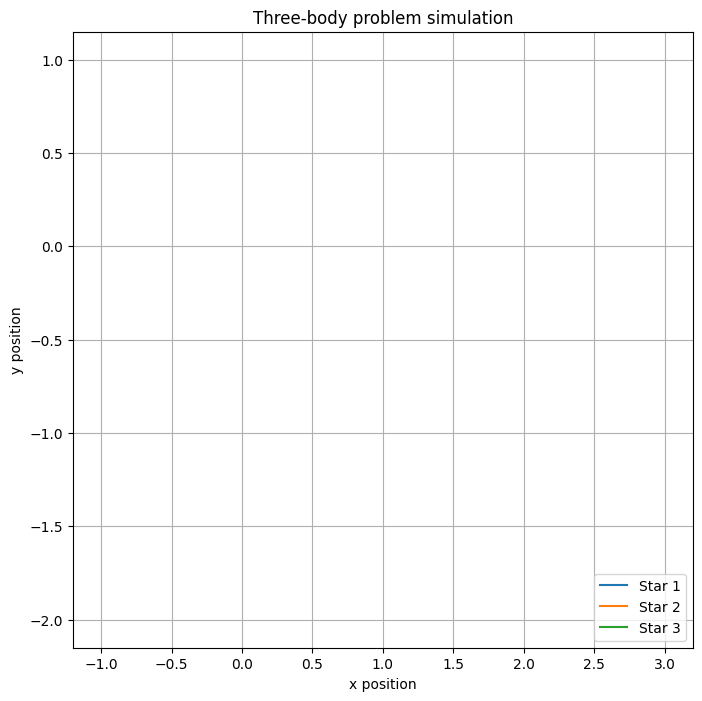

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.constants import G

# Define Mass of the Celestial Bodies:
m_1 = 150
m_2 = 200
m_3 = 250

# Define the position of the Celestial Bodies:
r_1 = np.array([3,1])
r_2 = np.array([-1, -2])
r_3 = np.array([-1,1])

def f(r,t):
  r_1_vec = r[0]
  r_2_vec = r[1]
  r_3_vec = r[2]
  v_1_vec = r[3]
  v_2_vec = r[4]
  v_3_vec = r[5]

  dr1 = v_1_vec
  dr2 = v_2_vec
  dr3 = v_3_vec

  dv1 = G * m_2 * (r_2_vec - r_1_vec) / np.linalg.norm(r_2_vec - r_1_vec)**3 + G * m_3 * (r_3_vec - r_1_vec) / np.linalg.norm(r_3_vec - r_1_vec)**3
  dv2 = G * m_1 * (r_1_vec - r_2_vec) / np.linalg.norm(r_1_vec - r_2_vec)**3 + G * m_3 * (r_3_vec - r_2_vec) / np.linalg.norm(r_3_vec - r_2_vec)**3
  dv3 = G * m_1 * (r_1_vec - r_3_vec) / np.linalg.norm(r_1_vec - r_3_vec)**3 + G * m_2 * (r_2_vec - r_3_vec) / np.linalg.norm(r_2_vec - r_3_vec)**3

  # The output of f should be a flattened array of derivatives
  # Order: dr1_x, dr1_y, dr2_x, dr2_y, dr3_x, dr3_y, dv1_x, dv1_y, dv2_x, dv2_y, dv3_x, dv3_y
  return np.array([dr1, dr2, dr3, dv1, dv2, dv3])

def rk4(f, r, t, h):
  k_1 = h * f(r,t)
  k_2 = h * f(r + 1/2*k_1, t + 1/2 * h)
  k_3 = h * f(r + 1/2*k_2, t + 1/2 * h)
  k_4 = h * f(r + k_3, t + h)
  return r + 1/6*(k_1 + 2 * k_2 + 2 * k_3 + k_4)

def rho_cal(f, r, t, h, delta):
  # take two steps of size h
  r1_val_mid = rk4(f, r, t, h)
  r1_val = rk4(f, r1_val_mid, t + h, h)
  # take one step of size 2h
  r2_val = rk4(f, r, t, 2*h)

  # The hints mention that r is a 6x2 array (3 position vectors, 3 velocity vectors)
  # So r1_val and r2_val will also be 6x2 arrays.
  # Error is in position of *any* star. Max error should be used.

  # Error for star 1 (position part of r_approx: r_approx[0])
  error1 = np.linalg.norm((r1_val[0] - r2_val[0]) / 30.0)
  # Error for star 2 (position part of r_approx: r_approx[1])
  error2 = np.linalg.norm((r1_val[1] - r2_val[1]) / 30.0)
  # Error for star 3 (position part of r_approx: r_approx[2])
  error3 = np.linalg.norm((r1_val[2] - r2_val[2]) / 30.0)

  # total error in position (maximum of errors for each star)
  error = max(error1, error2, error3)

  if error == 0:
      rho = float('inf')
  else:
      rho = h * delta / error
  return rho, r1_val

def h_cal(f, r, t, h, delta):
  rho, r1_val = rho_cal(f, r, t, h, delta)
  if rho >= 1.0:
    return h, r1_val, rho
  else:
    # Cap the decrease factor to a minimum of 0.5 (so it doesn't shrink by more than half at once)
    shrink_factor = max(rho ** (1/4), 0.5)
    h_new = h * shrink_factor
    # Recursive call to find a valid step size
    return h_cal(f, r, t, h_new, delta)

def adpt_rk4(f, t_start, t_end, h, delta, r0):
  t_set = [t_start]
  r_approx_list  = [r0] # Renamed to avoid conflict with the r parameter in f

  while t_set[-1] < t_end:
    # h_current is the valid h found for this step, l1 is the new position
    h_current, r_next_val, rho = h_cal(f, r_approx_list[-1], t_set[-1], h, delta)
    r_approx_list.append(r_next_val)
    t_set.append(t_set[-1] + 2*h_current)

    # See that we took steps using h_current which has rho > 1
    # therefore it's under our error estimates
    # We still need to update h for the next iteration.
    h = h_current * min(rho**(1/4), 2.0)

  return np.array(t_set), np.array(r_approx_list)

# r0 should be a 6x2 array: [r1_vec, r2_vec, r3_vec, v1_vec, v2_vec, v3_vec]
# All initial velocities are [0,0]
r0 = np.array([r_1, r_2, r_3, [0.0,0.0], [0.0,0.0],[0.0,0.0]])

# Manually tested different ending times we obtained good results for:
t_end = 2.0 # The problem states t=0 to t=2
# delta = 10^-3 in the position of any star per unit time step
delta = 1e-3 # As given in the problem statement.
h_init = 1e-3 # initial guess for h, starting with a small step size

time_steps, r_approx = adpt_rk4(f, 0, t_end, h_init, delta, r0)

# Plotting the trails of all three stars
plt.figure(figsize=(8,8))
plt.plot(r_approx[:,0,0], r_approx[:,0,1], label='Star 1')
plt.plot(r_approx[:,1,0], r_approx[:,1,1], label='Star 2')
plt.plot(r_approx[:,2,0], r_approx[:,2,1], label='Star 3')
plt.xlabel('x position')
plt.ylabel('y position')
plt.title('Three-body problem simulation')
plt.legend()
plt.grid(True)
plt.show()


**Pts /15**

**BONUS**

Make an animation of the motion of the three stars using either ``qdraw`` or ```VPython``` from $t=0$ to $t=10$. Make the stars different colors, you may also wish to make the stars different sizes based on their masses. You may wish to include a trail.

Constructing an animation with an adaptive step size is challenging, since the steps do not all correspond to the same amount of real time. The simplest thing to do is just to ignore the varying step size and make an animation as if there were all equal. This will give you a reasonable visualization of the motion, but it will look a little odd because the stars slow down, rather than speed up, as they come close together, because the adaptive calculation will take more steps in this region.

A better solution is to vary the frame rate of your animation, so that the frames run proportionately faster when $h$ is smaller, meaning the frame rate needs to be equal to $C/h$ for some constant $C$. However, very small values of $h$ will make the frame rate too fast.

You may be tempted to skip the animation, but it's worth it!!!

In [ ]:
# type code here

**BONUS Pts /5**

#### Total Problem 3: /20 pts

### Total HW Pts /55

AI use, help me debug and make some plots.